h_g: 683.4847111988726 W/m^2/K
Burn radiation heat flux: 100000.0 W/m^2
Final time stored: 300.0 s
Final graphite hot-face surface temperature: 438.5617067647792 K
Final graphite-phenolic interface temperature: 438.65903907954413 K
Final phenolic-stainless interface temperature: 445.02210648352764 K
Final stainless outer-surface temperature: 444.67326812655455 K
Maximum stainless temperature anywhere in steel: 461.11700748512396 K
Maximum stainless temperature anywhere in steel: 187.967007485124 °C
Saved MATLAB data file: graphite_phenolic_stainless_reconstructed.mat


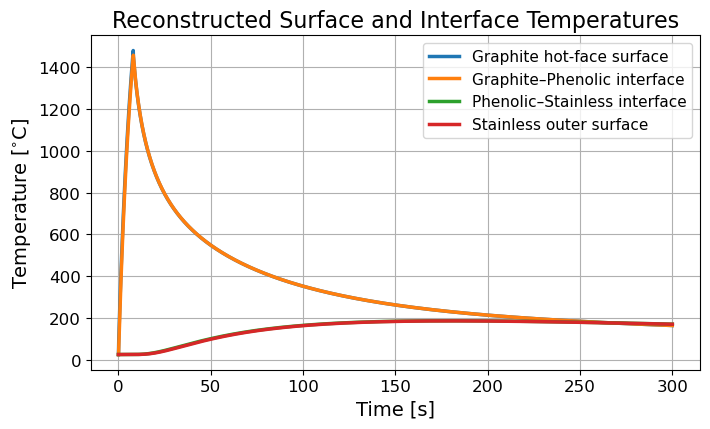

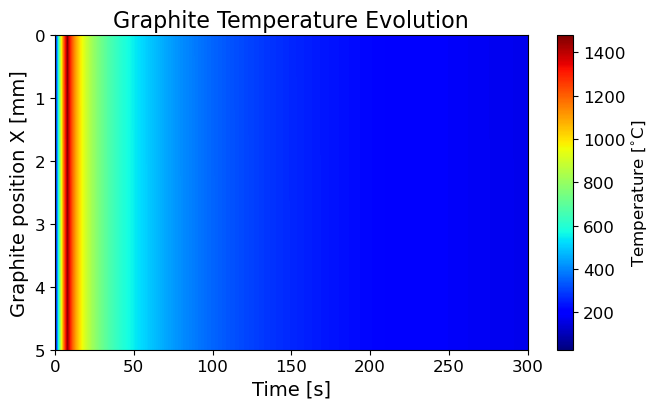

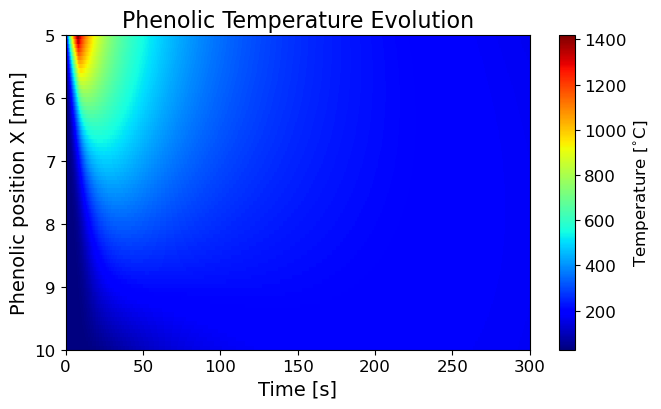

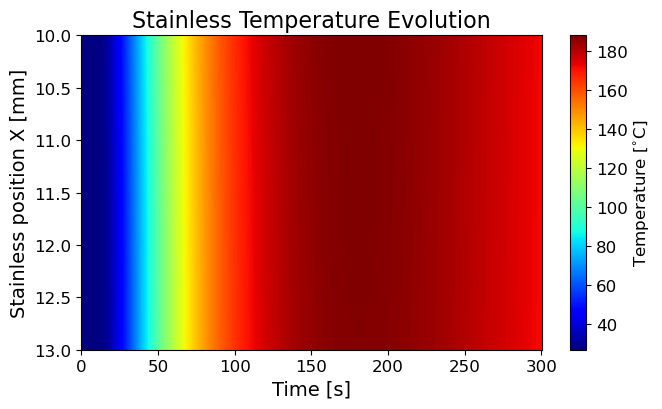

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from scipy.io import savemat
# 1D GRAPHITE + PHENOLIC + STAINLESS

# PHYSICAL PARAMETERS

# Graphite layer
k_g   = 130.0              # [W/m/K]
rho_g = 1720.0             # [kg/m^3]
cp_g  = 710.0              # [J/kg/K]
L_g0  = 0.005              # [m]
T0_g  = 300.0              # [K]

# Phenolic layer
k_p   = 0.25               # [W/m/K]
rho_p = 1200.0             # [kg/m^3]
cp_p  = 1310.0             # [J/kg/K]
L_p0  = 0.005              # [m]
T0_p  = 300.0              # [K]

# Stainless layer
k_s   = 16.0               # [W/m/K]
rho_s = 8000.0             # [kg/m^3]
cp_s  = 500.0              # [J/kg/K]
L_s0  = 0.003              # [m]
T0_s  = 300.0              # [K]

# HOT-SIDE HEATING / COOLING

T_gas   = 3000.0           # [K] during burn
T_amb   = 300.0            # [K] ambient
sigma   = 5.67e-8          # [W/m^2/K^4]

eps_g   = 0.90             # [-] graphite hot-face emissivity
eps_s   = 0.30             # [-] stainless outer-face emissivity

# Gas radiation heat flux during burn
q_rad_burn = 0.1e6         # [W/m^2] = 0.1 MW/m^2

# Chamber / convection correlation inputs
D_ch = 0.06                # [m]
L_ch = 0.370               # [m]
m_ox_total   = 3.60        # [kg]
m_fuel_total = 0.514       # [kg]
t_burn       = 8.0         # [s]
cp_gas       = 1.54        # [J/g-K]

S = (np.pi / 4.0) * D_ch**2
mdot = (m_ox_total + m_fuel_total) / t_burn
G = mdot / S

h_g = 3.075 * (cp_gas * (G**0.8) / (D_ch**0.2)) * (1.0 + (D_ch / L_ch)**0.7)

# Post-burn cooling
h_cool = 15.0              # [W/m^2/K] hot-side cooldown convection
h_out  = 15.0              # [W/m^2/K] outer-face convection
T_sur  = T_amb             # [K] surroundings for outer radiation

t_cool = 292.0
t_end  = t_burn + t_cool

# NUMERICAL PARAMETERS
dt = 0.025
nt = int(t_end / dt) + 1

# Cell counts per layer (cell-centred FV)
N_g = 76
N_p = 76
N_s = 51
N   = N_g + N_p + N_s

store_dt = 0.05
store_stride = max(1, int(store_dt / dt))

dx = np.zeros(N)
k  = np.zeros(N)
rho = np.zeros(N)
cp  = np.zeros(N)

# Graphite cells
dx[:N_g]   = L_g0 / N_g
k[:N_g]    = k_g
rho[:N_g]  = rho_g
cp[:N_g]   = cp_g

# Phenolic cells
i0 = N_g
i1 = N_g + N_p
dx[i0:i1]  = L_p0 / N_p
k[i0:i1]   = k_p
rho[i0:i1] = rho_p
cp[i0:i1]  = cp_p

# Stainless cells
i2 = i1
dx[i2:]    = L_s0 / N_s
k[i2:]     = k_s
rho[i2:]   = rho_s
cp[i2:]    = cp_s

# Cell-centre positions for plotting
x_g = (np.arange(N_g) + 0.5) * (L_g0 / N_g)
x_p = L_g0 + (np.arange(N_p) + 0.5) * (L_p0 / N_p)
x_s = L_g0 + L_p0 + (np.arange(N_s) + 0.5) * (L_s0 / N_s)

def reconstruct_interface(TL, TR, dxL, kL, dxR, kR):
    R_L = dxL / (2.0 * kL)
    R_R = dxR / (2.0 * kR)
    return (R_R * TL + R_L * TR) / (R_L + R_R)

def reconstruct_left_surface(T1, dx1, k1, h, T_inf, q_rad):
    G_left = 2.0 * k1 / dx1
    return (G_left * T1 + h * T_inf + q_rad) / (G_left + h)

def reconstruct_right_surface(TN, dxN, kN, h_out, h_rad, T_amb, T_sur):#
    G_right = 2.0 * kN / dxN
    return (G_right * TN + h_out * T_amb + h_rad * T_sur) / (G_right + h_out + h_rad)

def K_to_C(TK):
    return np.array(TK) - 273.15

g = np.empty(N - 1)

# graphite-graphite
g[:N_g - 1] = k_g / dx[0]

# graphite-phenolic interface
g[N_g - 1] = 1.0 / (dx[N_g - 1] / (2.0 * k_g) + dx[N_g] / (2.0 * k_p))

# phenolic-phenolic
g[N_g:i1 - 1] = k_p / dx[N_g]

# phenolic-stainless interface
g[i1 - 1] = 1.0 / (dx[i1 - 1] / (2.0 * k_p) + dx[i1] / (2.0 * k_s))

# stainless-stainless
g[i1:] = k_s / dx[i1]

# Conduction diagonal
diag_cond = np.zeros(N)
diag_cond[:-1] += g
diag_cond[1:]  += g

# Capacity diagonal
C_diag = rho * cp * dx

# INITIAL CONDITION
T = np.zeros(N)
T[:N_g]      = T0_g
T[N_g:i1]    = T0_p
T[i1:]       = T0_s

Tg_surf_prev = T0_g
Ts_surf_prev = T0_s

# STORAGE
max_store = nt
T_hist = np.zeros((max_store, N))
t_hist = np.zeros(max_store)

# Reconstructed quantities
Tg_surf_hist = np.zeros(max_store)   # graphite hot-face surface
Tgp_int_hist = np.zeros(max_store)   # graphite-phenolic interface
Tps_int_hist = np.zeros(max_store)   # phenolic-stainless interface
Ts_surf_hist = np.zeros(max_store)   # stainless outer surface

store_idx = 0
T_hist[store_idx] = T.copy()
t_hist[store_idx] = 0.0

Tg_surf_hist[store_idx] = T0_g
Tgp_int_hist[store_idx] = T0_g
Tps_int_hist[store_idx] = T0_g
Ts_surf_hist[store_idx] = T0_s
store_idx += 1

# TIME STEPPING
for n in range(1, nt):
    t = n * dt

    # Heating / cooling schedule
    if t > t_burn:
        h_g_eff   = h_cool
        T_gas_eff = T_amb

        # Hot-face Stefan-Boltzmann cooling to ambient
        # using reconstructed graphite surface temperature
        q_rad_g = eps_g * sigma * (T_amb**4 - Tg_surf_prev**4)
    else:
        h_g_eff   = h_g
        T_gas_eff = T_gas

        # Prescribed burn radiation heating
        q_rad_g = q_rad_burn

    # Boundary assembly
    diag = diag_cond.copy()
    f = np.zeros(N)

    # Left boundary: convection + radiation
    diag[0] += h_g_eff
    f[0] += h_g_eff * T_gas_eff + q_rad_g

    # Right boundary: convection + linearised radiation to ambient
    # using reconstructed outer surface temperature
    h_rad_out = 4.0 * eps_s * sigma * max(Ts_surf_prev, 1.0)**3
    diag[-1] += (h_out + h_rad_out)
    f[-1] += h_out * T_amb + h_rad_out * T_sur

    # Crank-Nicolson tridiagonal solve
    A_main  = C_diag + 0.5 * dt * diag
    A_lower = -0.5 * dt * g
    A_upper = -0.5 * dt * g

    B_main  = C_diag - 0.5 * dt * diag
    B_lower = +0.5 * dt * g
    B_upper = +0.5 * dt * g

    rhs = B_main * T
    rhs[1:]  += B_lower * T[:-1]
    rhs[:-1] += B_upper * T[1:]
    rhs += dt * f

    ab = np.zeros((3, N))
    ab[0, 1:]  = A_upper
    ab[1, :]   = A_main
    ab[2, :-1] = A_lower

    T = solve_banded((1, 1), ab, rhs)

    # Reconstruct surfaces / interfaces
    Tg_surf = reconstruct_left_surface(
        T1=T[0], dx1=dx[0], k1=k[0],
        h=h_g_eff, T_inf=T_gas_eff, q_rad=q_rad_g
    )

    Tgp_int = reconstruct_interface(
        TL=T[N_g - 1], TR=T[N_g],
        dxL=dx[N_g - 1], kL=k[N_g - 1],
        dxR=dx[N_g],     kR=k[N_g]
    )

    Tps_int = reconstruct_interface(
        TL=T[i1 - 1], TR=T[i1],
        dxL=dx[i1 - 1], kL=k[i1 - 1],
        dxR=dx[i1],     kR=k[i1]
    )

    Ts_surf = reconstruct_right_surface(
        TN=T[-1], dxN=dx[-1], kN=k[-1],
        h_out=h_out, h_rad=h_rad_out,
        T_amb=T_amb, T_sur=T_sur
    )

    # Update explicit-radiation surface temperatures
    Tg_surf_prev = Tg_surf
    Ts_surf_prev = Ts_surf

    if (n % store_stride == 0) or (n == nt - 1):
        T_hist[store_idx] = T.copy()
        t_hist[store_idx] = t

        Tg_surf_hist[store_idx] = Tg_surf
        Tgp_int_hist[store_idx] = Tgp_int
        Tps_int_hist[store_idx] = Tps_int
        Ts_surf_hist[store_idx] = Ts_surf

        store_idx += 1

T_hist       = T_hist[:store_idx]
t_hist       = t_hist[:store_idx]
Tg_surf_hist = Tg_surf_hist[:store_idx]
Tgp_int_hist = Tgp_int_hist[:store_idx]
Tps_int_hist = Tps_int_hist[:store_idx]
Ts_surf_hist = Ts_surf_hist[:store_idx]

# Maximum stainless temperature anywhere in the steel
Ts_max_K = np.max(T_hist[:, i1:])
Ts_max_C = Ts_max_K - 273.15

print("h_g:", h_g, "W/m^2/K")
print("Burn radiation heat flux:", q_rad_burn, "W/m^2")
print("Final time stored:", t_hist[-1], "s")
print("Final graphite hot-face surface temperature:", Tg_surf_hist[-1], "K")
print("Final graphite-phenolic interface temperature:", Tgp_int_hist[-1], "K")
print("Final phenolic-stainless interface temperature:", Tps_int_hist[-1], "K")
print("Final stainless outer-surface temperature:", Ts_surf_hist[-1], "K")
print("Maximum stainless temperature anywhere in steel:", Ts_max_K, "K")
print("Maximum stainless temperature anywhere in steel:", Ts_max_C, "°C")

# TEMPERATURE ARRAYS IN °C
Tg_surf_C = K_to_C(Tg_surf_hist)
Tgp_int_C = K_to_C(Tgp_int_hist)
Tps_int_C = K_to_C(Tps_int_hist)
Ts_surf_C = K_to_C(Ts_surf_hist)

Tg_matrix_C = K_to_C(T_hist[:, :N_g])
Tp_matrix_C = K_to_C(T_hist[:, N_g:(N_g + N_p)])
Ts_matrix_C = K_to_C(T_hist[:, (N_g + N_p):])

# EXPORT TO MAT FILE
export_data = {
    "t_hist": t_hist,

    # Reconstructed comparison temperatures
    "Tg_surf_C": Tg_surf_C,
    "Tgp_int_C": Tgp_int_C,
    "Tps_int_C": Tps_int_C,
    "Ts_surf_C": Ts_surf_C,

    # Heatmap data
    "Tg_matrix_C": Tg_matrix_C,
    "Tp_matrix_C": Tp_matrix_C,
    "Ts_matrix_C": Ts_matrix_C,

    # Positions for heatmaps [mm]
    "x_g_mm": x_g * 1000.0,
    "x_p_mm": x_p * 1000.0,
    "x_s_mm": x_s * 1000.0,

    # Extra outputs
    "Ts_max_K": np.array([Ts_max_K]),
    "Ts_max_C": np.array([Ts_max_C]),
}

savemat("graphite_phenolic_stainless_reconstructed.mat", export_data)
print("Saved MATLAB data file: graphite_phenolic_stainless_reconstructed.mat")

# PLOTS
TITLE_FS = 16
LABEL_FS = 14
TICK_FS  = 12
LEG_FS   = 11
CBAR_FS  = 12

# 1) Surfaces / interfaces vs time
plt.figure(figsize=(7.2, 4.4))
plt.plot(t_hist, Tg_surf_C, "-", linewidth=2.5, label="Graphite hot-face surface")
plt.plot(t_hist, Tgp_int_C, "-", linewidth=2.5, label="Graphite–Phenolic interface")
plt.plot(t_hist, Tps_int_C, "-", linewidth=2.5, label="Phenolic–Stainless interface")
plt.plot(t_hist, Ts_surf_C, "-", linewidth=2.5, label="Stainless outer surface")
plt.xlabel("Time [s]", fontsize=LABEL_FS)
plt.ylabel("Temperature [$^{\\circ}$C]", fontsize=LABEL_FS)
plt.title("Reconstructed Surface and Interface Temperatures", fontsize=TITLE_FS)
plt.grid(True)
plt.legend(fontsize=LEG_FS)
plt.xticks(fontsize=TICK_FS)
plt.yticks(fontsize=TICK_FS)
plt.tight_layout()
plt.show()

# 2) Graphite heatmap
plt.figure(figsize=(6.8, 4.2))
Xgrid_g = np.tile(t_hist[:, None], (1, Tg_matrix_C.shape[1]))
Ygrid_g = np.tile((x_g * 1000.0)[None, :], (len(t_hist), 1))
pcm_g = plt.pcolormesh(Xgrid_g, Ygrid_g, Tg_matrix_C, cmap='jet', shading='auto')
cbar = plt.colorbar(pcm_g)
cbar.set_label("Temperature [$^{\\circ}$C]", fontsize=CBAR_FS)
cbar.ax.tick_params(labelsize=TICK_FS)
plt.xlabel("Time [s]", fontsize=LABEL_FS)
plt.ylabel("Graphite position X [mm]", fontsize=LABEL_FS)
plt.title("Graphite Temperature Evolution", fontsize=TITLE_FS)
plt.xticks(fontsize=TICK_FS)
plt.yticks(fontsize=TICK_FS)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

# 3) Phenolic heatmap
plt.figure(figsize=(6.8, 4.2))
Xgrid_p = np.tile(t_hist[:, None], (1, Tp_matrix_C.shape[1]))
Ygrid_p = np.tile((x_p * 1000.0)[None, :], (len(t_hist), 1))
pcm_p = plt.pcolormesh(Xgrid_p, Ygrid_p, Tp_matrix_C, cmap='jet', shading='auto')
cbar = plt.colorbar(pcm_p)
cbar.set_label("Temperature [$^{\\circ}$C]", fontsize=CBAR_FS)
cbar.ax.tick_params(labelsize=TICK_FS)
plt.xlabel("Time [s]", fontsize=LABEL_FS)
plt.ylabel("Phenolic position X [mm]", fontsize=LABEL_FS)
plt.title("Phenolic Temperature Evolution", fontsize=TITLE_FS)
plt.xticks(fontsize=TICK_FS)
plt.yticks(fontsize=TICK_FS)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

# 4) Stainless heatmap
plt.figure(figsize=(6.8, 4.2))
Xgrid_s = np.tile(t_hist[:, None], (1, Ts_matrix_C.shape[1]))
Ygrid_s = np.tile((x_s * 1000.0)[None, :], (len(t_hist), 1))
pcm_s = plt.pcolormesh(Xgrid_s, Ygrid_s, Ts_matrix_C, cmap='jet', shading='auto')
cbar = plt.colorbar(pcm_s)
cbar.set_label("Temperature [$^{\\circ}$C]", fontsize=CBAR_FS)
cbar.ax.tick_params(labelsize=TICK_FS)
plt.xlabel("Time [s]", fontsize=LABEL_FS)
plt.ylabel("Stainless position X [mm]", fontsize=LABEL_FS)
plt.title("Stainless Temperature Evolution", fontsize=TITLE_FS)
plt.xticks(fontsize=TICK_FS)
plt.yticks(fontsize=TICK_FS)
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()